# Missing values in adaptive n-of-1 trials

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy
from adaptive_nof1 import *
from adaptive_nof1.policies import *
from adaptive_nof1.helpers import *
from adaptive_nof1.inference import *
from adaptive_nof1.metrics import *
from matplotlib import pyplot as plt

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [3]:
import numpy 
import random

import seaborn as sns

import sys
sys.path.append("..")

from missingness.missing_utils import *

from ast import literal_eval

/mnt/c/Users/Juliana/dev/adaptive_nof1/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulation Study 1: Thompson vs UCB

In [121]:
# Initial parameters 
block_length = 1
length = 28
number_of_actions = 2
number_of_patients = 100
percentage_missing = 0.3
num_patients_missing = 50
missing_mechanism = "random"
imputation_method_names = ["individual", "global"]
#["knn", "ind_tr", "global", "individual", "global_tr", "locf", "cluster", "dr"]
exists = True

random.seed(9001)

treatment_means = [1,0]
treatment_vars = [1,1]
effect_parameters_file_ending = f"{treatment_means[0]}{treatment_means[1]}"

In [122]:
generating_scenario_II = lambda patient_id: NormalModel(
    patient_id, mean=literal_eval(repr(treatment_means)), variance=[1, 1]
)

model_mapping = {
    f"NormalModel(({repr(treatment_means)}, [1, 1]))": "II",
}
policy_mapping = {
    "BlockPolicy(ThompsonSampling(NormalKnownVariance(0, 1, 1)))": "TS",
}

metrics = [
  #  SimpleRegretWithMean(),
 #   CumulativeRegret(),
    KLDivergence(
        data_to_true_distribution=data_to_true_distribution,
        debug_data_to_posterior_distribution=debug_data_to_torch_distribution,
    ),
]


# Inference Model
inference_model = lambda: NormalKnownVariance(
    prior_mean=0, prior_variance=1, variance=1
)

thompson_sampling_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=ThompsonSampling(
        inference_model=inference_model(),
    ),
)

# Full crossover study
study_designs = {
    "n_patients": [number_of_patients],
    "policy": [
        thompson_sampling_policy,
    ],
    "model_from_patient_id": [
        generating_scenario_II,
    ],
    "pooling": [False]
    
}
configurations_ind = generate_configuration_cross_product(study_designs)
configurations_pool = configurations_ind[0]
configurations_pool["pooling"] = True
configurations_pool = [configurations_pool]

In [123]:
results_path = "../missingness/results"

In [124]:
exists = False
save = False

In [125]:
all_calculated_series = {}
for imputation_method in imputation_method_names: 

    #### RETURN SIMULATIONS WITH IMPUTATION
    if not exists: 
        print(imputation_method)

        if imputation_method in ["individual", "ind_tr", "locf"]:
            configurations = configurations_ind
        else:
            configurations = configurations_pool
            
        calculated_series  = simulate_missing_configurations(
        configurations, length, percentage_missing, num_patients_missing, missing_mechanism,imputation_method)
        all_calculated_series[imputation_method] = calculated_series
        if save:
            pd.to_pickle(calculated_series, f"{results_path}/calculated_series_{imputation_method}_{missing_mechanism}_{effect_parameters_file_ending}.pkl")
        
    
    else:
    
        calculated_series = pd.read_pickle(f"{results_path}/calculated_series_{imputation_method}_{missing_mechanism}_{effect_parameters_file_ending}.pkl")
        all_calculated_series[imputation_method] = calculated_series

individual
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES
ZERO IN MISSES


  0%|                                                                                            | 0/28 [00:00<?, ?it/s]

THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS


  4%|███                                                                                 | 1/28 [00:00<00:12,  2.12it/s]

THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS


...

THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS


 96%|████████████████████████████████████████████████████████████████████████████████   | 27/28 [00:44<00:02,  2.29s/it]

THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS
THERE ARE ZEROS IN MISSINGS


100%|███████████████████████████████████████████████████████████████████████████████████| 28/28 [00:46<00:00,  1.67s/it]

THERE ARE ZEROS IN MISSINGS


In [126]:
all_df_results = {}
for imputation_method in imputation_method_names: 
    df_result = create_df_result(all_calculated_series[imputation_method])
    df_result["method"] = imputation_method
    all_df_results[imputation_method] = df_result

df_all_results = pd.concat(all_df_results)

In [127]:
df4 = df_all_results[df_all_results["patient_id"]==4]

In [128]:
df95 = df_all_results[df_all_results["patient_id"]==95]

In [129]:
df95[df95["missing"]==True].groupby("method")["t"].unique()

method
global        [0, 1, 3, 9, 16, 17, 19, 23]
individual    [0, 1, 3, 9, 16, 17, 19, 23]
Name: t, dtype: object

In [130]:
df4[df4["missing"]==True].groupby("method")["t"].unique()

method
global        [2, 6, 10, 15, 17, 20, 21, 26]
individual    [2, 6, 10, 15, 17, 20, 21, 26]
Name: t, dtype: object

## Some checks

In [113]:
miss_ids = df_all_results[df_all_results["missing"]==True].groupby("method")["patient_id"].unique()

In [114]:
miss_ids.iloc[0] = np.sort(miss_ids[0])

miss_ids.iloc[1] = np.sort(miss_ids[1])

/tmp/ipykernel_2707/703914433.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  miss_ids.iloc[0] = np.sort(miss_ids[0])
/tmp/ipykernel_2707/703914433.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  miss_ids.iloc[1] = np.sort(miss_ids[1])


In [115]:
miss_ids

method
global        [0, 4, 6, 7, 8, 9, 13, 16, 19, 20, 22, 25, 28,...
individual    [0, 4, 6, 7, 8, 9, 13, 16, 19, 20, 22, 25, 28,...
Name: patient_id, dtype: object

In [116]:
total_counts = df_all_results.groupby(["method","patient_id"])["missing"].count()

# Step 2: Count occurrences where missing == True
missing_counts = df_all_results.groupby(["method","patient_id"])["missing"].sum()  # sum() works since True=1, False=0

# Step 3: Compute percentage (only for patients who have at least one True)
missing_percentage = (missing_counts / total_counts) * 100
missing_percentage = missing_percentage[missing_counts > 0].reset_index()
#missing_percentage.columns = ["patient_id", "missing_percentage"]

print(missing_percentage)

        method  patient_id    missing
0       global           0  28.571429
1       global           4  28.571429
2       global           6  28.571429
3       global           7  28.571429
4       global           8  28.571429
..         ...         ...        ...
95  individual          92  28.571429
96  individual          93  28.571429
97  individual          94  28.571429
98  individual          95  28.571429
99  individual          97  28.571429

[100 rows x 3 columns]


In [117]:
imba_ids = missing_percentage[["patient_id","missing"]].drop_duplicates(keep=False)["patient_id"]

In [120]:
missing_percentage["missing"].value_counts()

missing
28.571429    100
Name: count, dtype: int64

In [118]:
pd.merge(missing_percentage[(missing_percentage["patient_id"].isin(imba_ids)) & (missing_percentage["method"]=="individual")],
missing_percentage[(missing_percentage["patient_id"].isin(imba_ids)) & (missing_percentage["method"]=="global")],on="patient_id")

,method_x,patient_id,missing_x,method_y,missing_y


In [37]:
(df_all_results[df_all_results["missing"]]
    .groupby("method")["patient_id"]
    .nunique()
    .reset_index(name="num_patients_with_missing"))

,method,num_patients_with_missing
0,global,500
1,global_tr,500
2,ind_tr,500
3,individual,500
4,knn,500
5,locf,500


In [38]:
total_counts = df_all_results.groupby(["method","patient_id"])["missing"].count()

# Step 2: Count occurrences where missing == True
missing_counts = df_all_results.groupby(["method","patient_id"])["missing"].sum()  # sum() works since True=1, False=0

# Step 3: Compute percentage (only for patients who have at least one True)
missing_percentage = (missing_counts / total_counts) * 100
missing_percentage = missing_percentage[missing_counts > 0].reset_index()
#missing_percentage.columns = ["patient_id", "missing_percentage"]

print(missing_percentage)

      method  patient_id    missing
0     global           2  25.000000
1     global           3  28.571429
2     global           4  25.000000
3     global           5  28.571429
4     global           7  28.571429
...      ...         ...        ...
2995    locf         989  28.571429
2996    locf         992  25.000000
2997    locf         996  28.571429
2998    locf         997  28.571429
2999    locf         998  25.000000

[3000 rows x 3 columns]


# Results

In [25]:
df_all_results.groupby(["method","treatment"])["outcome"].mean()

method      treatment
global      0            0.997869
            1           -0.404299
global_tr   0            1.006528
            1           -0.140107
ind_tr      0            0.992456
            1            0.357785
individual  0            0.999535
            1           -0.033659
knn         0            0.990034
            1           -0.127831
locf        0            0.988888
            1            0.065893
Name: outcome, dtype: float64

In [28]:
df_all_results.groupby(["method","treatment_miss"])["outcome_miss"].mean()

method      treatment_miss
global      0                 0.996367
            1                 0.270279
global_tr   0                 1.002336
            1                 0.208380
ind_tr      0                 0.990850
            1                 0.508433
individual  0                 0.999198
            1                 0.989210
knn         0                 0.990150
            1                 0.947525
locf        0                 0.988644
            1                 0.995032
Name: outcome_miss, dtype: float64

## Percentage of optimal treatment selection

In [205]:
optimal_miss_perc2 = df_all_results.groupby(['method'])['treatment_miss']\
   .value_counts(normalize=True)\
   .unstack()\
   .mul(100)\
   .round(2)\
   .fillna(0)

optimal_miss_perc2 = optimal_miss_perc2.reset_index().rename(columns={0:"percentage_miss_0",
                                               1:"percentage_miss_1"})

In [206]:
optimal_full_perc2 = df_all_results.groupby(['method'])['treatment']\
   .value_counts(normalize=True)\
   .unstack()\
   .mul(100)\
   .round(2)\
   .fillna(0)

optimal_full_perc2 = optimal_full_perc2.reset_index().rename(columns={0:"percentage_full_0",
                                               1:"percentage_full_1"})

In [207]:
pd.merge(optimal_full_perc2,optimal_miss_perc2,on="method")

,method,percentage_full_0,percentage_full_1,percentage_miss_0,percentage_miss_1
0,global,99.97,0.03,99.95,0.05
1,individual,99.96,0.04,97.15,2.85


In [158]:
pd.merge(optimal_full_perc,optimal_miss_perc,on="method")

,method,percentage_full_0,percentage_full_1,percentage_miss_0,percentage_miss_1
0,global,99.97,0.03,99.95,0.05
1,global_tr,99.96,0.04,99.95,0.05
2,ind_tr,99.90,0.10,99.87,0.13
3,individual,99.96,0.04,97.15,2.85
4,knn,99.96,0.04,98.56,1.44
5,locf,99.94,0.06,90.56,9.44


In [176]:
optimal_miss_abs = pd.DataFrame(df_all_results.groupby(["method"])["treatment_miss"].value_counts()).reset_index()
optimal_miss_abs.columns = ["method","treatment","count_miss"]

In [175]:
optimal_full_abs = df_all_results.groupby(["method"])["treatment"].value_counts().reset_index()
optimal_full_abs.columns = ["method","treatment","count_full"]

In [180]:
optimal_abs = pd.merge(optimal_full_abs,optimal_miss_abs,on=["method","treatment"])
optimal_abs[optimal_abs["treatment"]==0]

,method,treatment,count_full,count_miss
0,global,0,27992,27986
2,global_tr,0,27990,27986
4,ind_tr,0,27971,27963
6,individual,0,27988,27203
8,knn,0,27989,27597
10,locf,0,27984,25358


# KL divergence

In [68]:
def kl_divergence_norm(mu_p, sigma_p, mu_q, sigma_q):
    """Compute KL divergence D_KL(P || Q) for two normal distributions."""
    return np.log(sigma_q / sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5

In [91]:
means_vars_obs = df_all_results.groupby(["method","treatment"])["outcome"].agg({lambda x:(np.mean(x),np.var(x))}).reset_index()

means_vars_obs.rename(columns={"<lambda>":"means_vars"},inplace=True)

In [92]:
means_vars_miss = df_all_results.groupby(["method","treatment"])["outcome_miss"].agg({lambda x:(np.mean(x),np.var(x))}).reset_index()

means_vars_miss.rename(columns={"<lambda>":"means_vars"},inplace=True)

In [83]:
true_mu_0, true_sigma_0 = (treatment_means[0],treatment_vars[0])
true_mu_1, true_sigma_1 = (treatment_means[1],treatment_vars[1])


In [120]:
miss_true_kl = pd.DataFrame(columns=["method","treatment","KL_miss_true"], index=range(len(imputation_method_names)))
for i, row in means_vars_miss.iterrows():
    method = row["method"]
    treatment = row["treatment"]
    mean = row["means_vars"][0]
    sigma = row["means_vars"][1]
    if treatment == 0:
        true_mu = true_mu_0
        true_sigma = true_sigma_0
    else:
        true_mu = true_mu_1
        true_sigma = true_sigma_1
    kl = kl_divergence_norm(mean, sigma, true_mu, true_sigma)
    miss_true_kl.loc[i,"method"] = method
    miss_true_kl.loc[i,"treatment"] = treatment
    miss_true_kl.loc[i,"KL_miss_true"] = kl 

In [119]:
obs_true_kl = pd.DataFrame(columns=["method","treatment","KL_obs_true"], index=range(len(imputation_method_names)))


for i, row in means_vars_obs.iterrows():
    method = row["method"]
    treatment = row["treatment"]
    mean = row["means_vars"][0]
    sigma = row["means_vars"][1]
    if treatment == 0:
        true_mu = true_mu_0
        true_sigma = true_sigma_0
    else:
        true_mu = true_mu_1
        true_sigma = true_sigma_1
    kl = kl_divergence_norm(mean, sigma, true_mu, true_sigma)
    obs_true_kl.loc[i,"method"] = method
    obs_true_kl.loc[i,"treatment"] = treatment
    obs_true_kl.loc[i,"KL_obs_true"] = kl 

In [118]:
obs_miss_kl = pd.DataFrame(columns=["method","treatment","KL_obs_miss"], index=range(len(imputation_method_names)))

for i, row in means_vars_miss.iterrows():
    method = row["method"]
    treatment = row["treatment"]
    mean = row["means_vars"][0]
    sigma = row["means_vars"][1]
    mean_full = means_vars_obs.iloc[i]["means_vars"][0]
    sigma_full = means_vars_obs.iloc[i]["means_vars"][1]
    kl = kl_divergence_norm(mean, sigma, mean_full, sigma_full)
    obs_miss_kl.loc[i,"method"] = method
    obs_miss_kl.loc[i,"treatment"] = treatment
    obs_miss_kl.loc[i,"KL_obs_miss"] = kl 

In [115]:
kl_divs = pd.merge(obs_true_kl, miss_true_kl, on=["method","treatment"])

In [116]:
kl_divs = pd.merge(obs_miss_kl, kl_divs, on=["method","treatment"])

In [117]:
kl_divs

,method,treatment,KL_obs_miss,KL_obs_true,KL_miss_true
0,global,0,0.019648,0.000029,0.020983
1,global,1,0.084486,0.467825,0.346777
2,global_tr,0,0.01783,0.000125,0.020399
3,global_tr,1,0.1435,0.025746,0.258338
4,ind_tr,0,0.018556,0.00012,0.021046
5,ind_tr,1,0.054951,0.067639,0.089635
6,individual,0,0.019625,0.00013,0.022633
7,individual,1,0.000576,0.001223,0.003189
8,knn,0,0.016167,0.000135,0.018439
9,knn,1,0.016117,0.063545,0.026109


## Descriptives & visual comparison

<Axes: xlabel='t', ylabel='value'>

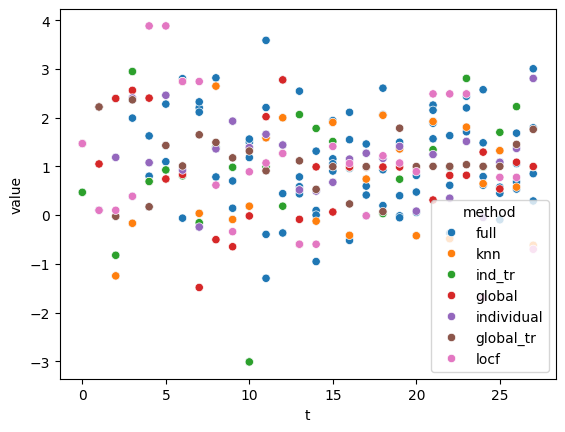

In [36]:
df_plot =pd.melt(df_all_results[df_all_results["patient_id"]==4],
       id_vars=["method","patient_id","t","treatment","treatment_miss"],
       value_vars=["outcome","outcome_miss"])

df_plot.loc[df_plot["variable"]=="outcome","method"] = "full"

df_plot.drop_duplicates(inplace=True)

sns.scatterplot(df_plot,x="t",y="value",hue="method")

In [78]:
df_all_results.groupby("method")["outcome"]

In [79]:
import seaborn as sns

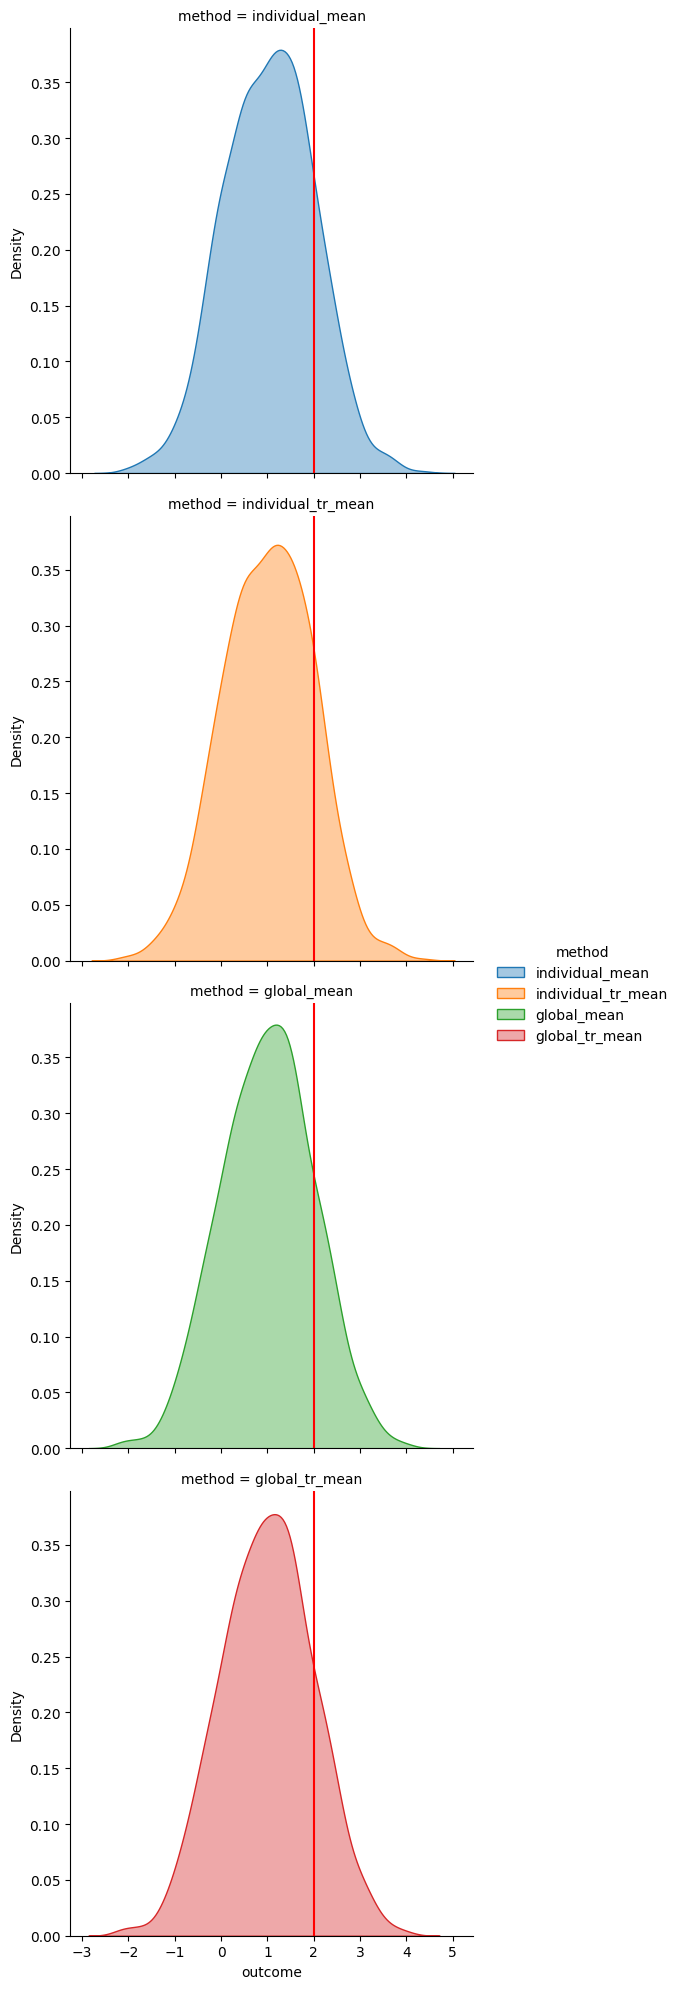

In [92]:
g = sns.displot(kind='kde', data=df_all_results[df_all_results["treatment"]==0], x='outcome', row="method", hue="method", fill=True, common_norm=False, alpha=0.4)
for ax in g.axes.flat:
    ax.axvline(2,color="red")

## Posterior difference plots

In [106]:
posterior_diff = df_all_results.groupby(["method","patient_id"]).apply(lambda x:x[x["treatment"]==0]["outcome"].reset_index(drop=True) - x[x["treatment"]==1]["outcome"].reset_index(drop=True)).reset_index()

/tmp/ipykernel_1260/3697512091.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  posterior_diff = df_all_results.groupby(["method","patient_id"]).apply(lambda x:x[x["treatment"]==0]["outcome"].reset_index(drop=True) - x[x["treatment"]==1]["outcome"].reset_index(drop=True)).reset_index()


In [107]:
posterior_diff_miss = df_all_results.groupby(["method","patient_id"]).apply(lambda x:x[x["treatment"]==0]["outcome_miss"].reset_index(drop=True) - x[x["treatment"]==1]["outcome_miss"].reset_index(drop=True)).reset_index()

/tmp/ipykernel_1260/1480872915.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  posterior_diff_miss = df_all_results.groupby(["method","patient_id"]).apply(lambda x:x[x["treatment"]==0]["outcome_miss"].reset_index(drop=True) - x[x["treatment"]==1]["outcome_miss"].reset_index(drop=True)).reset_index()


In [103]:
posterior_tru = np.random.normal(2, 1, df_all_results.shape[0])
posterior_tru_0 = np.random.normal(0, 1, df_all_results[df_all_results["treatment"]==0].shape[0])
posterior_tru_1 = np.random.normal(2, 1, df_all_results[df_all_results["treatment"]==1].shape[0])

In [112]:
posterior_diff["diff"] = "full"
posterior_diff_miss["diff"] = "miss"

In [122]:
all_posterior_diff = pd.concat([posterior_diff,posterior_diff_miss.rename(columns={"outcome_miss":"outcome"})],axis=0).reset_index(drop=True)

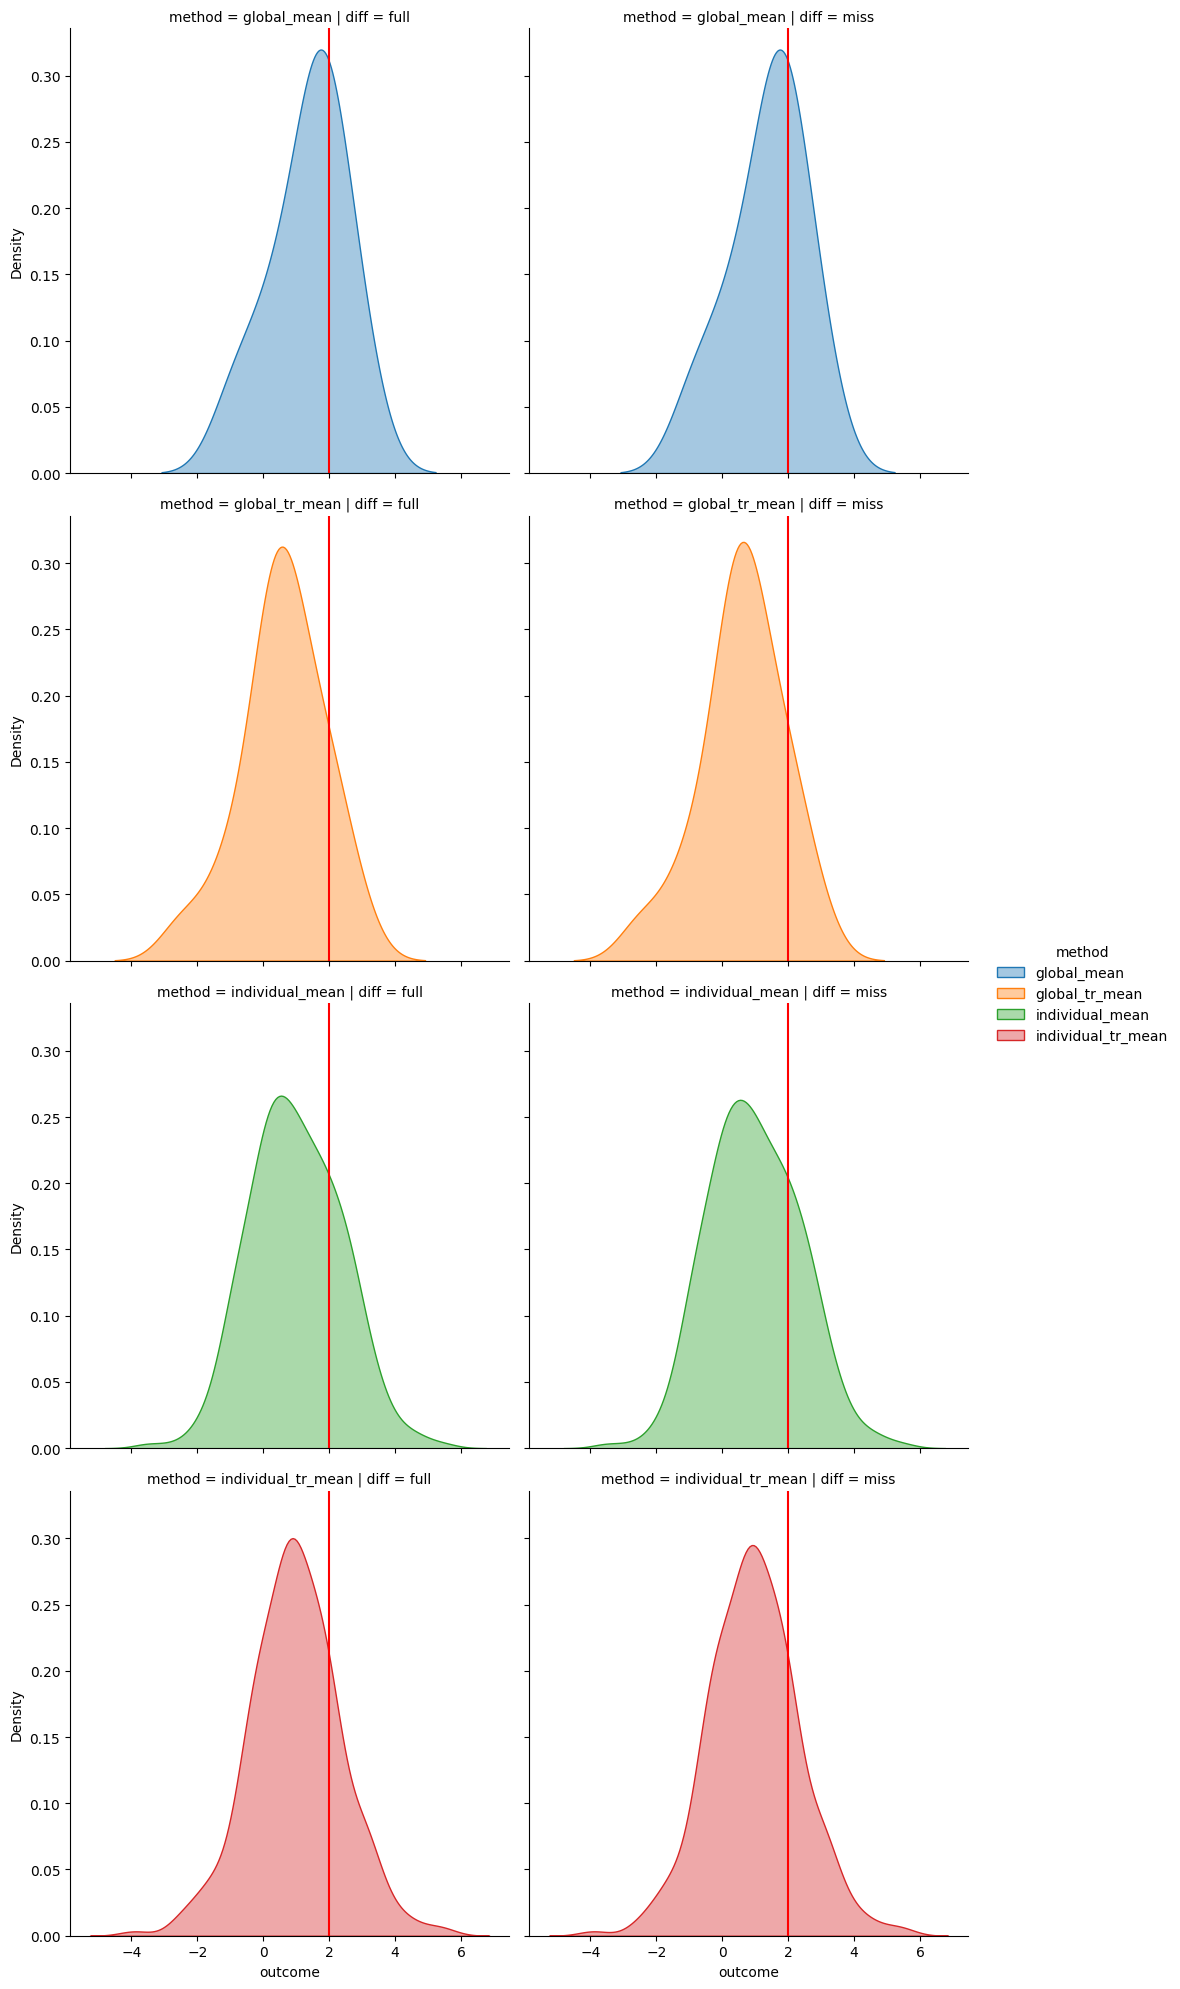

In [124]:
g = sns.displot(kind='kde', data=all_posterior_diff, x='outcome', col="diff",row="method", hue="method", fill=True, common_norm=False, alpha=0.4)
for ax in g.axes.flat:
    ax.axvline(2,color="red")

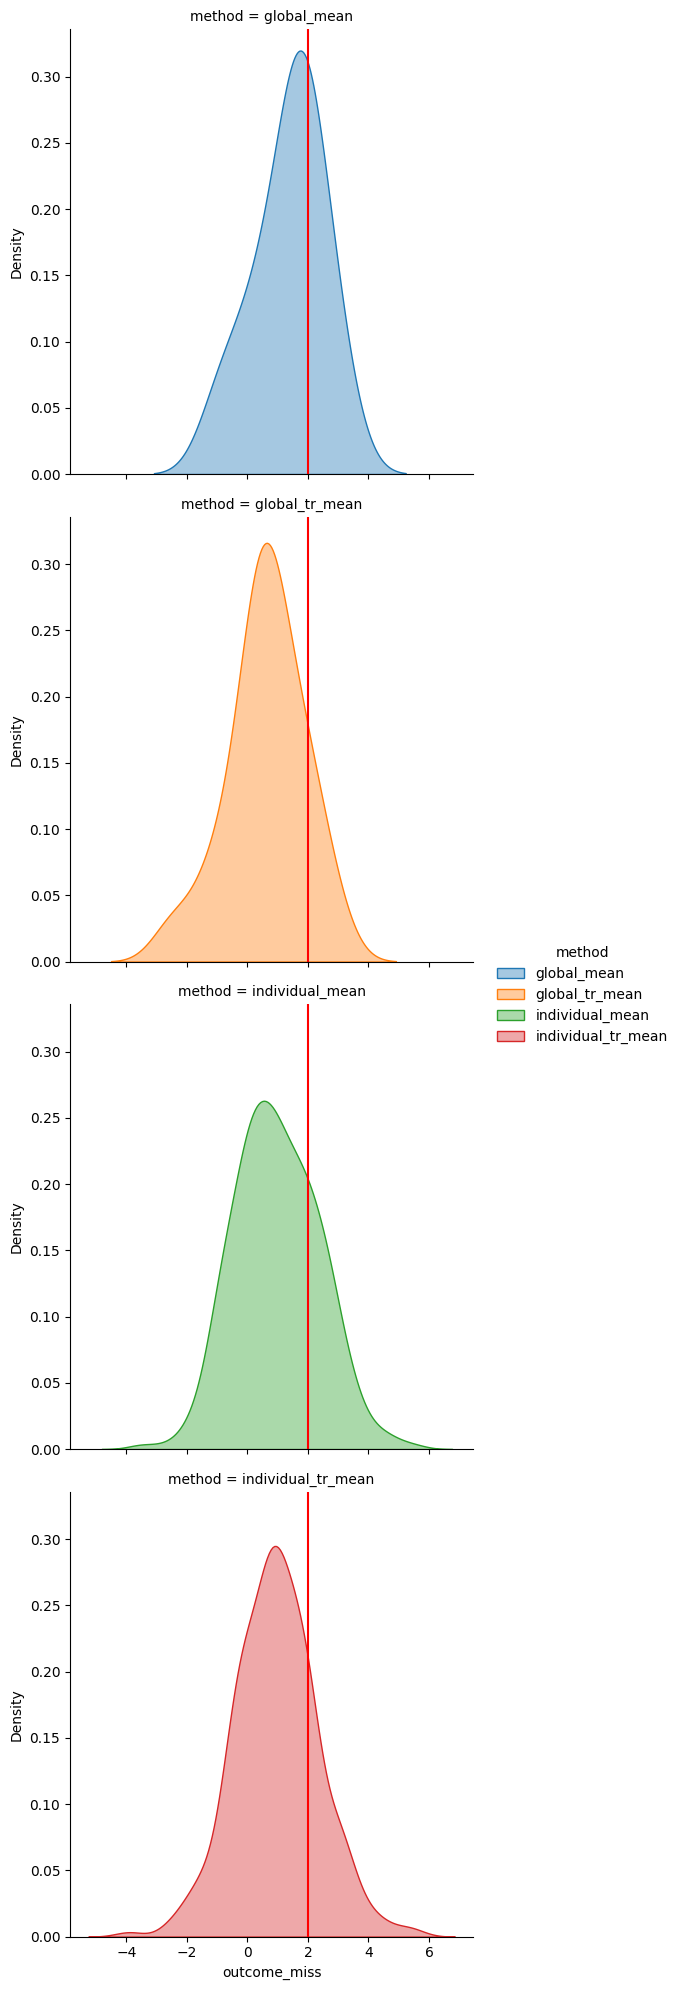

In [117]:
g = sns.displot(kind='kde', data=posterior_diff_miss, x='outcome_miss', row="method", hue="method", fill=True, common_norm=False, alpha=0.4)
for ax in g.axes.flat:
    ax.axvline(2,color="red")

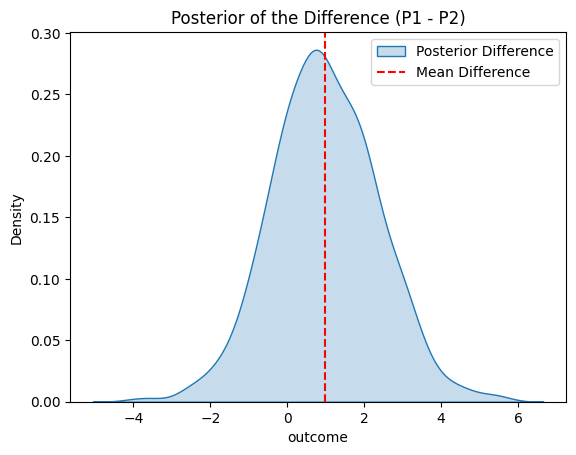

In [108]:
# Plot the result
sns.kdeplot(posterior_diff["outcome"], fill=True, label="Posterior Difference")
plt.axvline(np.mean(posterior_diff["outcome"]), color="red", linestyle="--", label="Mean Difference")
plt.legend()
plt.title("Posterior of the Difference (P1 - P2)")
plt.show()

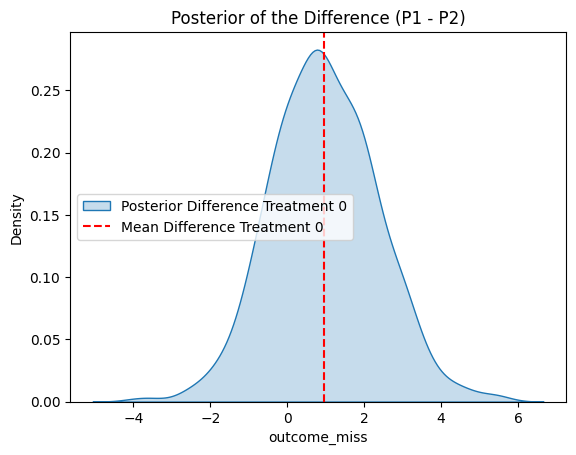

In [125]:
# Plot the result
sns.kdeplot(posterior_diff_miss["outcome_miss"], fill=True, label="Posterior Difference Treatment 0")
plt.axvline(np.mean(posterior_diff_miss["outcome_miss"]), color="red", linestyle="--", label="Mean Difference Treatment 0")
plt.legend()
plt.title("Posterior of the Difference (P1 - P2)")
plt.show()

In [21]:
# Data Generation Model
class PooledNormalModel(Model):
    def __init__(self, patient_id, prior_mean, prior_variance, variance):
        self.rng = numpy.random.default_rng(patient_id)
        self.prior_mean = prior_mean
        self.prior_variance = prior_variance
        self.variance = variance
        self.patient_id = patient_id

        # Draw patient effects randomly:
        self.mean = self.rng.normal(prior_mean, numpy.sqrt(prior_variance))

    def generate_context(self, history):
        return {}

    @property
    def additional_config(self):
        return {"expectations_of_interventions": self.mean}

    @property
    def number_of_interventions(self):
        return len(self.prior_mean)

    def observe_outcome(self, action, context, missing=False):
        treatment_index = action["treatment"]
        outcome = self.rng.normal(
                self.mean[treatment_index], numpy.sqrt(self.variance[treatment_index])
            )
        if missing:
            return {
                "outcome_miss": outcome
            }
        else:
            return {
            "outcome": outcome
        }

    def __str__(self):
        return (
            f"PooledNormalModel({self.prior_mean, self.prior_variance, self.variance})"
        )

In [22]:
# Inference Model


class PooledNormalWithKnownVariance(BayesianModel):
    def __str__(self):
        return f"PooledNormalWithKnownVariance"

    def update_posterior(self, history, number_of_treatments):
        # Simple model with baseline + treatment effects + noise
        df = history.to_df()

        self.model = pymc.Model()
        with self.model:
            treatment_index = pymc.MutableData(
                "treatment_index",
                pymc.intX(df[self.treatment_name]),
                dims="observation",
            )
            patient_index = pymc.MutableData(
                "patient_index", pymc.intX(df["patient_id"]), dims="observation"
            )
            sigma = pymc.Uniform("sigma", lower=0.1, upper=2.0)
            mu_treatment = pymc.Normal(
                "mu_treatment", mu=0, sigma=sigma, dims="treatment", shape=2
            )
            mu_treatment_patient = pymc.Normal(
                "mu_patient_treatment",
                mu=mu_treatment,
                sigma=1,
                dims=("patient", "treatment"),
                shape=(10, 2),
            )
            outcome = pymc.Normal(
                "outcome",
                mu=mu_treatment_patient[patient_index, treatment_index],
                observed=df["outcome"],
                sigma=1,
                dims="observation",
                shape=len(df["outcome"]),
            )
            self.trace = pymc.sample(2000, progressbar=False)

    def approximate_max_probabilities(self, number_of_treatments, context):
        assert (
            self.trace is not None
        ), "You called `approximate_max_probabilites` without updating the posterior"

        # Todo: we need to use the patient_id here
        patient_id = context["patient_id"]
        self.patient_id = patient_id
        with self.model:
            pymc.set_data(
                {
                    "treatment_index": pymc.intX([0, 1]),
                    "patient_index": pymc.intX([patient_id] * 2),
                }
            )
            self.trace = pymc.sample_posterior_predictive(
                self.trace,
                var_names=["mu_patient_treatment"],
                extend_inferencedata=True,
            )
            max_indices = np.ravel(
                self.trace.posterior_predictive["mu_patient_treatment"].argmax(
                    dim="treatment"
                )
            )
        bin_counts = np.bincount(max_indices, minlength=number_of_treatments)
        return bin_counts / np.sum(bin_counts)

    def get_upper_confidence_bounds(self, variable_name, epsilon: float = 0.05):
        confidence_bounds = arviz.hdi(
            self.trace.posterior_predictive,
            var_names=[variable_name],
            hdi_prob=1 - epsilon,
        )
        # The data containts always (lower, upper) for all patients, and we only want higher for the right patient
        return confidence_bounds[variable_name][self.patient_id, :, 1].to_numpy()


generating_pooling_scenario_VI = lambda patient_id: PooledNormalModel(
    patient_id, prior_mean=[1, 0], prior_variance=[0.8, 0.8], variance=[1, 1]
)
generating_pooling_scenario_VII = lambda patient_id: PooledNormalModel(
    patient_id, prior_mean=[1, 0], prior_variance=[1.5, 1.5], variance=[1, 1]
)

In [23]:
# Policies
pooled_fixed_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=FixedPolicy(
        inference_model=PooledNormalWithKnownVariance(),
    ),
)

pooled_thompson_sampling_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=ThompsonSampling(
        inference_model=PooledNormalWithKnownVariance(),
        outcome_name="mu_patient_treatment",
    ),
)

pooled_ucb_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=UpperConfidenceBound(
        inference_model=PooledNormalWithKnownVariance(),
        outcome_name="mu_patient_treatment",
        epsilon=0.05,
    ),
)

In [24]:
configurations = []
# Pooling
study_designs = {
    "n_patients": [10],
    "policy": [pooled_ucb_policy, pooled_thompson_sampling_policy],
    "model_from_patient_id": [
        generating_pooling_scenario_VI,
        generating_pooling_scenario_VII,
    ],
    "pooling": [True],
}
configurations.extend(generate_configuration_cross_product(study_designs))

In [28]:
plot_allocations_for_calculated_series(calculated_series)

:Layout
   .HeatMap.I    :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.I    :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.II   :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.II   :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.III  :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.III  :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.IV   :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.IV   :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.V    :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.V    :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.VI   :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.VI   :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.VII  :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.VII  :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]
   .HeatMap.VIII :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.VIII :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]

In [29]:
metrics = [
    SimpleRegretWithBayesian(),
    CumulativeRegret(),
]
df = SeriesOfSimulationsData.score_data(
    [s["result"] for s in calculated_series],
    metrics,
    {"model": lambda x: model_mapping[x], "policy": lambda x: policy_mapping[x]},
)
filtered_df = df.loc[df["t"] == df["t"].max()]

groupby_columns = ["model", "policy"]
pivoted_df = filtered_df.pivot(
    index=["model", "policy", "simulation", "patient_id"],
    columns="metric",
    values="score",
)


policy_ordering = ["UCB", "TS", "Pooled TS", "Pooled UCB"]
table = pivoted_df.groupby(groupby_columns).agg(["mean", "std"])
# Convert the 'policy' column in the MultiIndex to a Categorical type with the specified order
table = table.reset_index()
table["policy"] = pd.Categorical(
    table["policy"], categories=policy_ordering, ordered=True
)

# Sort the DataFrame first by 'model' then by the now-ordered 'policy'
sorted_table = (
    table.sort_values(by=["model", "policy"])
    .set_index(groupby_columns)
    .rename(
        columns={
            "Cumulative Regret (outcome)": "Regret",
            "Simple Regret With Mean": "$\SIR$",
            "Best Arm Identification With Mean": "$\BAI$",
            "KL Divergence": "$\KLD$",
        },
    )
)
# sorted_table.index.names = ["S.", "Policy"]
sorted_table

metric               Regret            Simple Regret With Bayesian Model  \
                       mean        std                              mean   
model policy                                                               
VI    UCB        -17.898502  24.639971                          0.041770   
      TS         -22.688316  30.365568                          0.035299   
      Pooled TS  -12.749280  22.920278                          0.000000   
      Pooled UCB -21.740085  27.063883                          0.000000   
VII   UCB        -24.825855  41.822308                          0.000000   
      TS         -23.640568  43.080548                          0.062216   
      Pooled TS  -14.156254  33.140194                          0.028070   
      Pooled UCB -20.635655  34.379455                          0.028070   

metric                      
                       std  
model policy                
VI    UCB         0.111227  
      TS          0.111626  
      Pooled TS   0.000000  
      Pooled UCB  0.000000  
VII   UCB         0.000000  
      TS          0.160720  
      Pooled TS   0.088765  
      Pooled UCB  0.088765

In [31]:
with open("mt_resources/5-optimization/02-table-pooling.tex", "w") as file:
    str = sorted_table.style.format(precision=2).to_latex(hrules=True)
    print(str)
    file.write(str)

\begin{tabular}{llrrrr}
\toprule
 & metric & \multicolumn{2}{r}{Regret} & \multicolumn{2}{r}{Simple Regret With Bayesian Model} \\
 &  & mean & std & mean & std \\
model & policy &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{VI} & UCB & -17.90 & 24.64 & 0.04 & 0.11 \\
 & TS & -22.69 & 30.37 & 0.04 & 0.11 \\
 & Pooled TS & -12.75 & 22.92 & 0.00 & 0.00 \\
 & Pooled UCB & -21.74 & 27.06 & 0.00 & 0.00 \\
\multirow[c]{4}{*}{VII} & UCB & -24.83 & 41.82 & 0.00 & 0.00 \\
 & TS & -23.64 & 43.08 & 0.06 & 0.16 \\
 & Pooled TS & -14.16 & 33.14 & 0.03 & 0.09 \\
 & Pooled UCB & -20.64 & 34.38 & 0.03 & 0.09 \\
\bottomrule
\end{tabular}



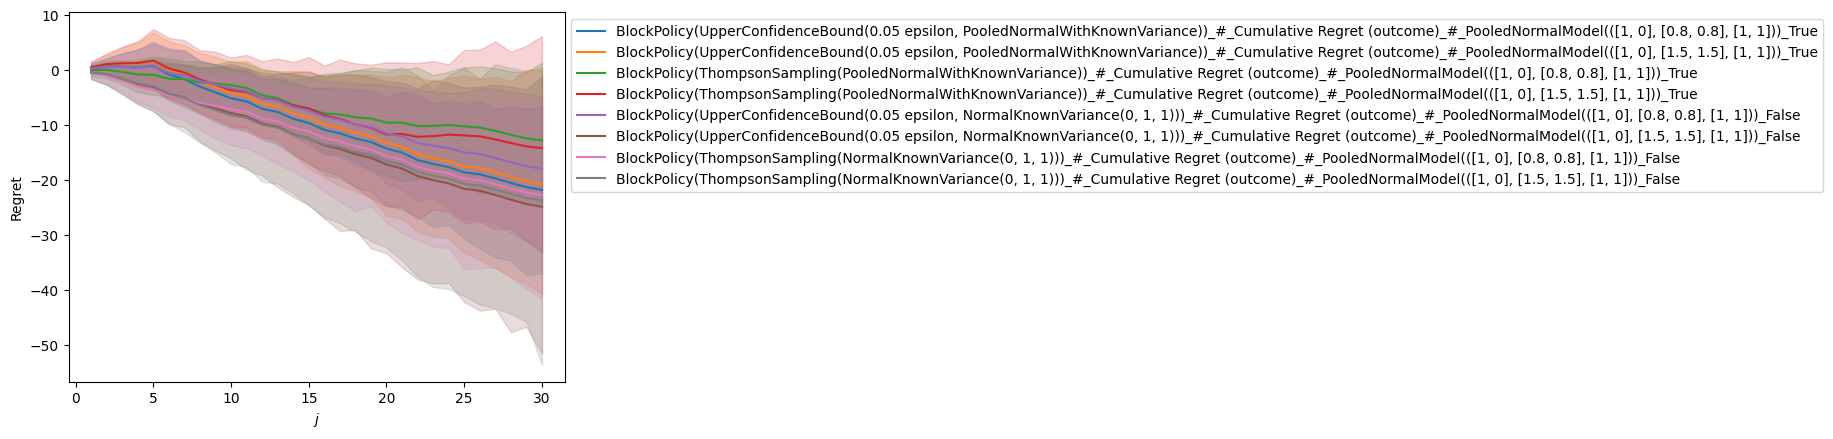

In [30]:
def rename_df(df):
    df["policy_#_metric_#_model_p"] = df["policy"].apply(lambda x: policy_mapping[x])
    df["policy_#_metric_#_model_p"] = pd.Categorical(
        df["policy_#_metric_#_model_p"], categories=policy_ordering, ordered=True
    )
    return df


SeriesOfSimulationsData.plot_lines(
    [s["result"] for s in calculated_series],
    [
        CumulativeRegret(),
    ],
    legend_position=(1, 1),
)
plt.savefig(
    "mt_resources/5-optimization/03_pooled_cumulative_regret.pdf", bbox_inches="tight"
)

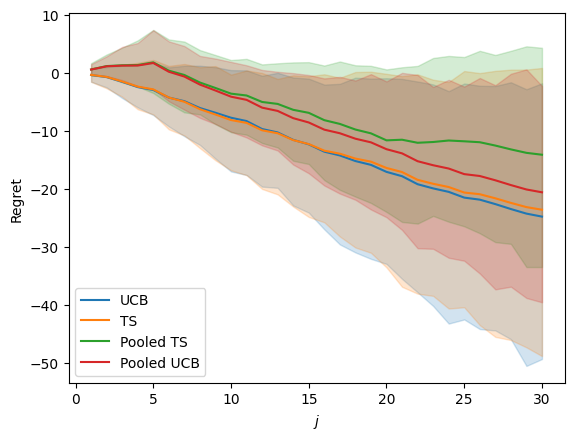

In [31]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ],
    [
        CumulativeRegret(),
    ],
    legend_position=(0.02, 0.3),
    process_df=rename_df,
)
plt.ylabel("Regret")

seaborn.move_legend(ax, "lower left", title=None)
plt.savefig(
    "mt_resources/5-optimization/03-pooled-cumulative_regret_high_sigma.pdf",
    bbox_inches="tight",
)

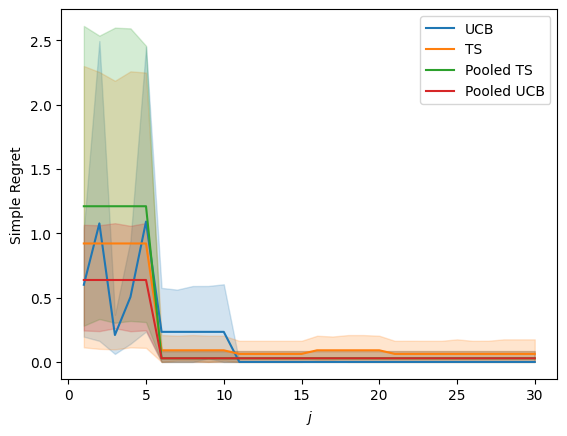

In [32]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ],
    [
        SimpleRegretWithBayesian(),
    ],
    process_df=rename_df,
)
plt.ylabel("Simple Regret")

seaborn.move_legend(ax, "upper right", title=None)
plt.savefig(
    "mt_resources/5-optimization/03-pooled-simple_regret-high-sigma.pdf",
    bbox_inches="tight",
)

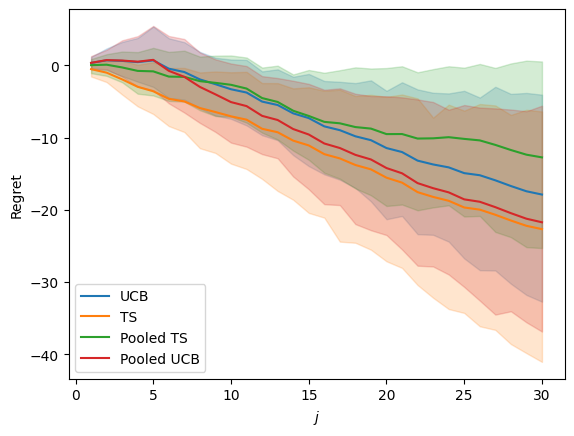

In [33]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ],
    [
        CumulativeRegret(),
    ],
    legend_position=(0.02, 0.3),
    process_df=rename_df,
)
plt.ylabel("Regret")
seaborn.move_legend(ax, "lower left", title=None)
plt.savefig(
    "mt_resources/5-optimization/03-pooled-cumulative_regret-low_sigma.pdf",
    bbox_inches="tight",
)

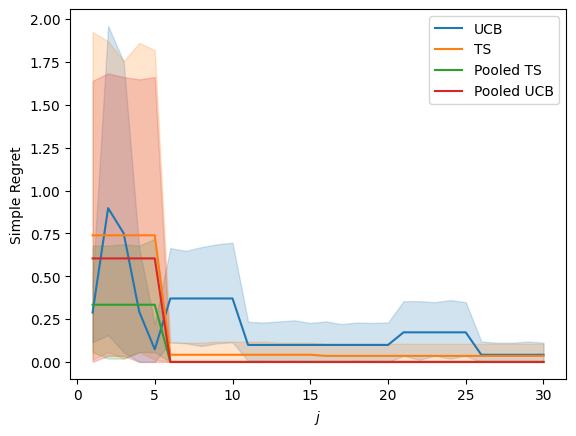

In [34]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ],
    [
        SimpleRegretWithBayesian(),
    ],
    process_df=rename_df,
)

seaborn.move_legend(ax, "upper right", title=None)
plt.ylabel("Simple Regret")
plt.savefig(
    "mt_resources/5-optimization/03-pooled-simple_regret-low_sigma.pdf",
    bbox_inches="tight",
)

In [35]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(UpperConfidenceBound(0.05 epsilon, PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ]
)

:Layout
   .HeatMap.I :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.I :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]

In [36]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(UpperConfidenceBound(0.05 epsilon, PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ]
)

:Layout
   .HeatMap.I :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.I :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]

In [37]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(ThompsonSampling(PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ]
)

:Layout
   .HeatMap.I :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.I :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]

In [38]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(ThompsonSampling(PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ]
)

:Layout
   .HeatMap.I :HeatMap   [j,i]   (color_index,debug_info,context,outcome,counterfactual_outcomes,debug_data,treatment)
   .Overlay.I :Overlay
      .Rectangles.I  :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.I        :Text   [x,y]
      .Rectangles.II :Rectangles   [x0,y0,x1,y1]   (value)
      .Text.II       :Text   [x,y]